<a href="https://colab.research.google.com/github/Ritapaz/simulacao-logistica/blob/vrp/Previs%C3%A3o_de_atrasos_no_transporte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estudo de caso envolvendo a previsão de atrasos no transporte. Nesse cenário, o tempo de entrega é modelado como uma variável aleatória, influenciada por diferentes fatores (trânsito, clima, capacidade operacional).

A partir da simulação de múltiplos cenários, é possível estimar:
- A probabilidade de atraso superior a um determinado limite;

- O impacto médio do atraso no custo logístico;

- Comparações entre diferentes políticas de transporte ou níveis de capacidade.

Esse tipo de análise ilustra de forma concreta como a simulação de Monte Carlo contribui para decisões mais informadas e estratégicas na logística empresarial.

In [91]:
import numpy as np

# 1. Definir o tempo médio de entrega base e sua variabilidade
tempo_entrega_base_medio = 8  # horas
desvio_padrao_tempo_entrega_base = 1.5 # horas

# 2. Criar parâmetros para simular fatores de atraso
# Fator: Tráfego Intenso
prob_trafego_intenso = 0.3
impacto_medio_trafego = 2   # horas adicionais
desvio_padrao_impacto_trafego = 0.5 # horas

# Fator: Clima Adverso
prob_clima_adverso = 0.2
impacto_medio_clima = 1.5  # horas adicionais
desvio_padrao_impacto_clima = 0.4 # horas

# Fator: Problemas de Capacidade Operacional
prob_capacidade_operacional = 0.1
impacto_medio_capacidade = 3 # horas adicionais
desvio_padrao_impacto_capacidade = 0.8 # horas

# 3. Definir um limite de atraso significativo
limite_atraso_significativo = 10 # horas de tempo total de entrega

# 4. Definir o custo logístico por hora de atraso
custo_por_hora_atraso = 50 # R$ por hora após o limite ser excedido

print("Parâmetros da simulação definidos com sucesso.")

def simular_cenario_entrega():
    # 1. Gerar o tempo de entrega base
    tempo_entrega_base = max(0, np.random.normal(tempo_entrega_base_medio, desvio_padrao_tempo_entrega_base))

    # 3. Inicializar atraso total de fatores
    atraso_total_fatores = 0

    # 4. Simular fatores de atraso
    # Tráfego Intenso
    if np.random.rand() < prob_trafego_intenso:
        impacto_trafego = max(0, np.random.normal(impacto_medio_trafego, desvio_padrao_impacto_trafego))
        atraso_total_fatores += impacto_trafego

    # Clima Adverso
    if np.random.rand() < prob_clima_adverso:
        impacto_clima = max(0, np.random.normal(impacto_medio_clima, desvio_padrao_impacto_clima))
        atraso_total_fatores += impacto_clima

    # Problemas de Capacidade Operacional
    if np.random.rand() < prob_capacidade_operacional:
        impacto_capacidade = max(0, np.random.normal(impacto_medio_capacidade, desvio_padrao_impacto_capacidade))
        atraso_total_fatores += impacto_capacidade

    # 5. Calcular o tempo de entrega final
    tempo_entrega_final = tempo_entrega_base + atraso_total_fatores

    # 6. Calcular o atraso significativo
    atraso_significativo = max(0, tempo_entrega_final - limite_atraso_significativo)

    # 7. Calcular o custo de atraso
    custo_atraso = atraso_significativo * custo_por_hora_atraso

    # 8. Retornar os resultados
    return tempo_entrega_final, atraso_significativo, custo_atraso

print("Função 'simular_cenario_entrega' definida com sucesso.")

num_simulacoes = 10000

tempos_entrega_finais = []
atrasos_significativos = []
custos_atraso = []

for _ in range(num_simulacoes):
    tempo_entrega, atraso_sig, custo = simular_cenario_entrega()
    tempos_entrega_finais.append(tempo_entrega)
    atrasos_significativos.append(atraso_sig)
    custos_atraso.append(custo)

print(f"Simulação de {num_simulacoes} cenários concluída.")
print(f"Total de tempos de entrega finais registrados: {len(tempos_entrega_finais)}")

Parâmetros da simulação definidos com sucesso.
Função 'simular_cenario_entrega' definida com sucesso.
Simulação de 10000 cenários concluída.
Total de tempos de entrega finais registrados: 10000


In [92]:
import numpy as np


# 1. Probabilidade de atraso significativo
probabilidade_atraso_significativo = np.sum(np.array(atrasos_significativos) > 0) / num_simulacoes

# 2. Impacto médio dos atrasos no custo logístico
custo_medio_atraso = np.mean(custos_atraso)

# 3. Tempo médio de entrega final
tempo_medio_entrega_final = np.mean(tempos_entrega_finais)

# 4. Desvio padrão do tempo de entrega final
desvio_padrao_tempo_entrega_final = np.std(tempos_entrega_finais)

print("\n--- Análise dos Resultados da Simulação ---")
print(f"Número total de simulações: {num_simulacoes}")
print(f"Probabilidade de atraso significativo (> {limite_atraso_significativo} horas): {probabilidade_atraso_significativo:.2%}")
print(f"Impacto médio do atraso no custo logístico: R$ {custo_medio_atraso:,.2f}")
print(f"Tempo médio de entrega final: {tempo_medio_entrega_final:.2f} horas")
print(f"Desvio padrão do tempo de entrega final: {desvio_padrao_tempo_entrega_final:.2f} horas")
print("------------------------------------------")


--- Análise dos Resultados da Simulação ---
Número total de simulações: 10000
Probabilidade de atraso significativo (> 10 horas): 33.08%
Impacto médio do atraso no custo logístico: R$ 25.40
Tempo médio de entrega final: 9.19 horas
Desvio padrão do tempo de entrega final: 2.09 horas
------------------------------------------


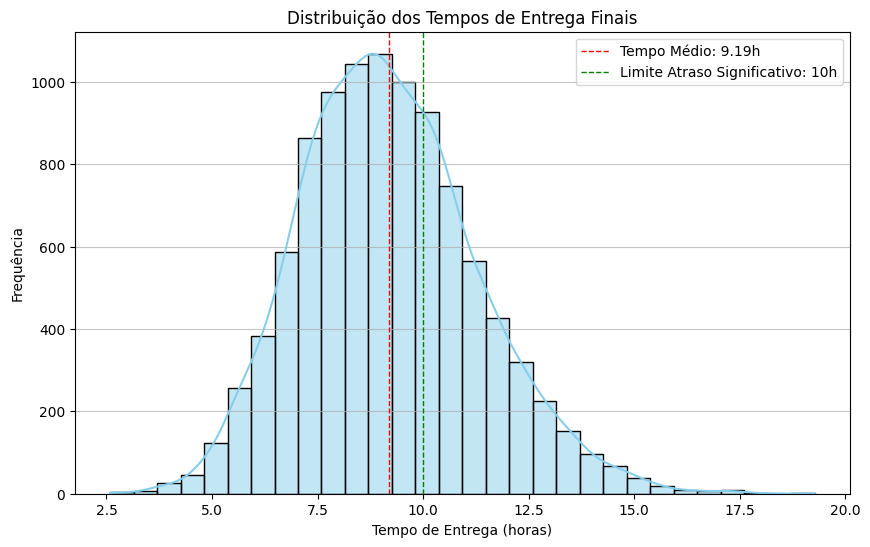

Histograma dos tempos de entrega finais gerado com sucesso.


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(tempos_entrega_finais, bins=30, kde=True, color='skyblue')
plt.axvline(tempo_medio_entrega_final, color='red', linestyle='dashed', linewidth=1, label=f'Tempo Médio: {tempo_medio_entrega_final:.2f}h')
plt.axvline(limite_atraso_significativo, color='green', linestyle='dashed', linewidth=1, label=f'Limite Atraso Significativo: {limite_atraso_significativo}h')
plt.title('Distribuição dos Tempos de Entrega Finais')
plt.xlabel('Tempo de Entrega (horas)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Histograma dos tempos de entrega finais gerado com sucesso.")

# Tarefa
Realize uma simulação de Monte Carlo para analisar atrasos no transporte. A simulação deve modelar o tempo de entrega como uma variável aleatória influenciada por fatores como tráfego, condições climáticas e capacidade operacional, utilizando distribuições de probabilidade apropriadas. Configure e execute a simulação para um grande número de iterações (por exemplo, de 10.000 a 100.000), armazenando os resultados para cada cenário. Analise a saída da simulação para estimar a probabilidade de atrasos que excedam um limite especificado e o impacto médio dos atrasos nos custos logísticos. Visualize os resultados usando gráficos adequados (por exemplo, histogramas dos tempos de entrega e gráficos de barras das probabilidades de atraso) e apresente um resumo dos principais achados e de suas implicações para decisões em logística empresarial.

## Definir Parâmetros da Simulação

### Subtarefa:
Definir os parâmetros iniciais para a simulação de Monte Carlo, incluindo o tempo médio de entrega, a variabilidade (por exemplo, desvio padrão), e os fatores que podem influenciar os atrasos (trânsito, clima, capacidade operacional). Isso pode ser feito usando distribuições de probabilidade apropriadas para cada variável.


**Raciocínio**:
O usuário deseja definir os parâmetros iniciais para a simulação de Monte Carlo, incluindo o tempo base de entrega, a variabilidade, os fatores que influenciam os atrasos (tráfego, clima e capacidade operacional), o limite de atraso e o custo por hora de atraso. Definir esses parâmetros em um bloco de código em Python.



In [94]:
import numpy as np

# 1. Definir o tempo médio de entrega base e sua variabilidade
tempo_entrega_base_medio = 8  # horas
desvio_padrao_tempo_entrega_base = 1.5 # horas

# 2. Criar parâmetros para simular fatores de atraso
# Fator: Tráfego Intenso
prob_trafego_intenso = 0.3
impacto_medio_trafego = 2   # horas adicionais
desvio_padrao_impacto_trafego = 0.5 # horas

# Fator: Clima Adverso
prob_clima_adverso = 0.2
impacto_medio_clima = 1.5  # horas adicionais
desvio_padrao_impacto_clima = 0.4 # horas

# Fator: Problemas de Capacidade Operacional
prob_capacidade_operacional = 0.1
impacto_medio_capacidade = 3 # horas adicionais
desvio_padrao_impacto_capacidade = 0.8 # horas

# 3. Definir um limite de atraso significativo
limite_atraso_significativo = 10 # horas de tempo total de entrega

# 4. Definir o custo logístico por hora de atraso
custo_por_hora_atraso = 50 # R$ por hora após o limite ser excedido

print("Parâmetros da simulação definidos com sucesso.")

Parâmetros da simulação definidos com sucesso.


## Configurar a Simulação de Monte Carlo

### Subtarefa:
Criar uma função ou estrutura que represente um único cenário de transporte. Esta função deve amostrar aleatoriamente os valores para os parâmetros definidos na etapa anterior e calcular o tempo de entrega resultante e, se aplicável, o atraso.


**Raciocínio**:
O usuário deseja definir uma função em Python que simule um único cenário de entrega com base nos parâmetros definidos na etapa anterior. Essa função irá calcular o tempo final de entrega, a ocorrência de atraso significativo e o custo associado.



In [95]:
def simular_cenario_entrega():
    # 1. Gerar o tempo de entrega base
    tempo_entrega_base = max(0, np.random.normal(tempo_entrega_base_medio, desvio_padrao_tempo_entrega_base))

    # 3. Inicializar atraso total de fatores
    atraso_total_fatores = 0

    # 4. Simular fatores de atraso
    # Tráfego Intenso
    if np.random.rand() < prob_trafego_intenso:
        impacto_trafego = max(0, np.random.normal(impacto_medio_trafego, desvio_padrao_impacto_trafego))
        atraso_total_fatores += impacto_trafego

    # Clima Adverso
    if np.random.rand() < prob_clima_adverso:
        impacto_clima = max(0, np.random.normal(impacto_medio_clima, desvio_padrao_impacto_clima))
        atraso_total_fatores += impacto_clima

    # Problemas de Capacidade Operacional
    if np.random.rand() < prob_capacidade_operacional:
        impacto_capacidade = max(0, np.random.normal(impacto_medio_capacidade, desvio_padrao_impacto_capacidade))
        atraso_total_fatores += impacto_capacidade

    # 5. Calcular o tempo de entrega final
    tempo_entrega_final = tempo_entrega_base + atraso_total_fatores

    # 6. Calcular o atraso significativo
    atraso_significativo = max(0, tempo_entrega_final - limite_atraso_significativo)

    # 7. Calcular o custo de atraso
    custo_atraso = atraso_significativo * custo_por_hora_atraso

    # 8. Retornar os resultados
    return tempo_entrega_final, atraso_significativo, custo_atraso

print("Função 'simular_cenario_entrega' definida com sucesso.")

Função 'simular_cenario_entrega' definida com sucesso.


## Executar a Simulação

### Subtarefa:
Rodar a simulação de Monte Carlo um grande número de vezes (por exemplo, 10.000 ou 100.000 iterações). Cada iteração representará um cenário de transporte diferente. Armazenar os resultados (tempo de entrega, atraso) de cada iteração.


**Raciocínio**:

A subtarefa requer executar a simulação de Monte Carlo para um grande número de iterações e armazenar os resultados. Este bloco de código irá definir o número de simulações, inicializar listas para guardar os resultados e, em seguida, percorrer o número especificado de simulações, chamando a função previamente definida e adicionando suas saídas às listas.


In [96]:
num_simulacoes = 10000

tempos_entrega_finais = []
atrasos_significativos = []
custos_atraso = []

for _ in range(num_simulacoes):
    tempo_entrega, atraso_sig, custo = simular_cenario_entrega()
    tempos_entrega_finais.append(tempo_entrega)
    atrasos_significativos.append(atraso_sig)
    custos_atraso.append(custo)

print(f"Simulação de {num_simulacoes} cenários concluída.")
print(f"Total de tempos de entrega finais registrados: {len(tempos_entrega_finais)}")

Simulação de 10000 cenários concluída.
Total de tempos de entrega finais registrados: 10000


## Analisar Resultados da Simulação

### Subtarefa:
Com base nos resultados da simulação, calcular a probabilidade de atraso superior a um determinado limite, o impacto médio do atraso no custo logístico, e outras métricas relevantes. Também pode-se comparar diferentes políticas de transporte ou níveis de capacidade se forem incluídos como variáveis na simulação.


**Raciocínio**:
É necessário calcular a probabilidade de atraso significativo, o impacto médio dos atrasos nos custos logísticos, o tempo médio final de entrega e o desvio padrão do tempo final de entrega com base nos resultados da simulação. Em seguida, imprimir esses resultados.


In [97]:
import numpy as np

# 1. Probabilidade de atraso significativo
probabilidade_atraso_significativo = np.sum(np.array(atrasos_significativos) > 0) / num_simulacoes

# 2. Impacto médio dos atrasos no custo logístico
custo_medio_atraso = np.mean(custos_atraso)

# 3. Tempo médio de entrega final
tempo_medio_entrega_final = np.mean(tempos_entrega_finais)

# 4. Desvio padrão do tempo de entrega final
desvio_padrao_tempo_entrega_final = np.std(tempos_entrega_finais)

print("\n--- Análise dos Resultados da Simulação ---")
print(f"Número total de simulações: {num_simulacoes}")
print(f"Probabilidade de atraso significativo (> {limite_atraso_significativo} horas): {probabilidade_atraso_significativo:.2%}")
print(f"Impacto médio do atraso no custo logístico: R$ {custo_medio_atraso:,.2f}")
print(f"Tempo médio de entrega final: {tempo_medio_entrega_final:.2f} horas")
print(f"Desvio padrão do tempo de entrega final: {desvio_padrao_tempo_entrega_final:.2f} horas")
print("------------------------------------------")


--- Análise dos Resultados da Simulação ---
Número total de simulações: 10000
Probabilidade de atraso significativo (> 10 horas): 33.28%
Impacto médio do atraso no custo logístico: R$ 26.06
Tempo médio de entrega final: 9.23 horas
Desvio padrão do tempo de entrega final: 2.09 horas
------------------------------------------


## Visualizar Resultados da Simulação

### Subtarefa:
Visualizar os resultados da simulação usando gráficos apropriados. Isso inclui um histograma dos tempos de entrega finais e, possivelmente, um gráfico de barras para a probabilidade de atraso ou o impacto médio no custo.



**Raciocínio**:
Para visualizar a distribuição dos tempos finais de entrega, vou gerar um histograma utilizando os dados tempos_entrega_finais. Isso ajudará a compreender quais são os tempos de entrega mais frequentes e como eles se distribuem.



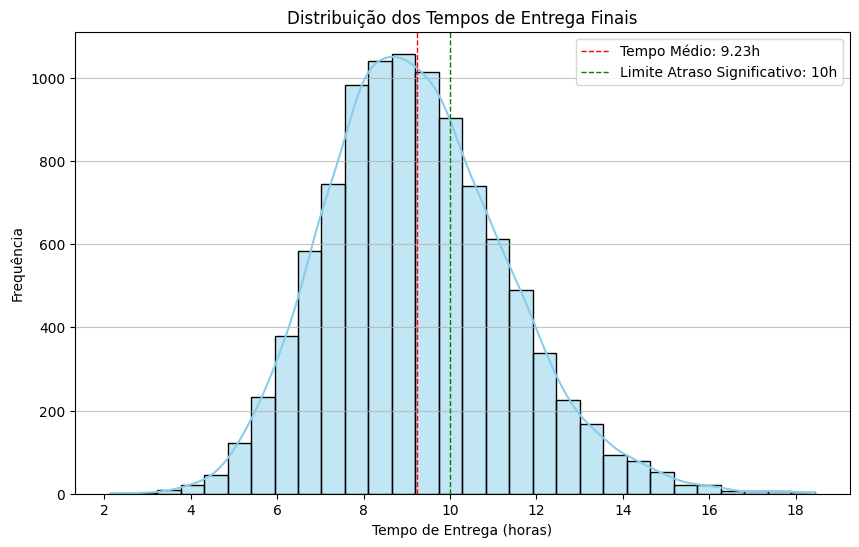

Histograma dos tempos de entrega finais gerado com sucesso.


In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(tempos_entrega_finais, bins=30, kde=True, color='skyblue')
plt.axvline(tempo_medio_entrega_final, color='red', linestyle='dashed', linewidth=1, label=f'Tempo Médio: {tempo_medio_entrega_final:.2f}h')
plt.axvline(limite_atraso_significativo, color='green', linestyle='dashed', linewidth=1, label=f'Limite Atraso Significativo: {limite_atraso_significativo}h')
plt.title('Distribuição dos Tempos de Entrega Finais')
plt.xlabel('Tempo de Entrega (horas)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Histograma dos tempos de entrega finais gerado com sucesso.")

**Raciocínio**:
Para visualizar ainda mais os resultados da simulação, conforme solicitado na subtarefa, criar um gráfico de barras mostrando a probabilidade de atraso significativo e o impacto médio nos custos logísticos. Isso fornecerá uma comparação visual clara dessas métricas-chave.



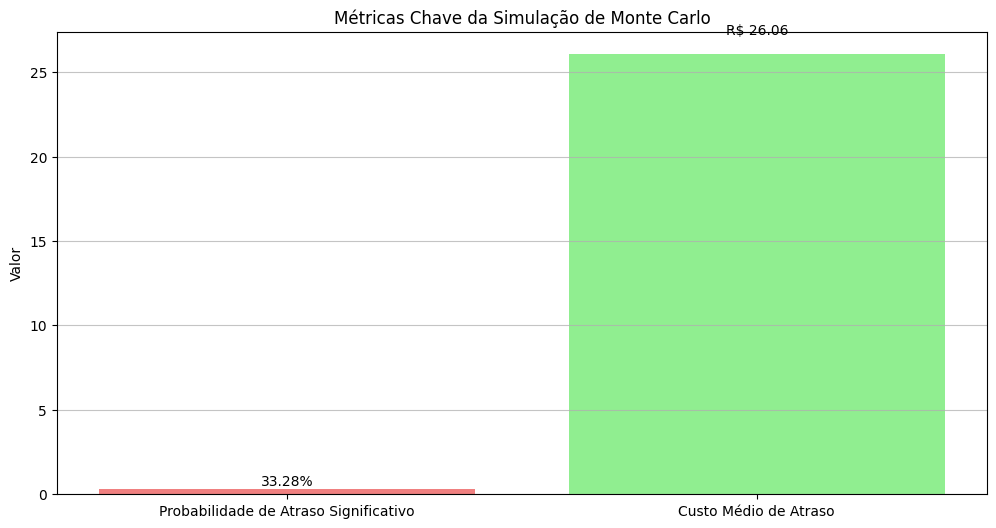

Gráfico de barras para probabilidade de atraso e custo médio gerado com sucesso.


In [99]:
plt.figure(figsize=(12, 6))

metrics = ['Probabilidade de Atraso Significativo', 'Custo Médio de Atraso']
values = [probabilidade_atraso_significativo, custo_medio_atraso]

# Create a bar plot for the metrics
plt.bar(metrics, values, color=['lightcoral', 'lightgreen'])

# Add value labels on top of the bars
for i, value in enumerate(values):
    if metrics[i] == 'Probabilidade de Atraso Significativo':
        plt.text(i, value + 0.01, f'{value:.2%}', ha='center', va='bottom')
    else:
        plt.text(i, value + 1, f'R$ {value:,.2f}', ha='center', va='bottom')

plt.title('Métricas Chave da Simulação de Monte Carlo')
plt.ylabel('Valor')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Gráfico de barras para probabilidade de atraso e custo médio gerado com sucesso.")

## Tarefa Final

### Subtarefa:
Apresentar um resumo das descobertas da simulação de Monte Carlo, destacando as principais conclusões sobre os atrasos no transporte e suas implicações.


## Resumo:

### Principais Resultados da Análise de Dados

*   A simulação de Monte Carlo foi configurada com um tempo base de entrega médio de 8 horas (com desvio padrão de 1,5 hora) e incluiu atrasos probabilísticos decorrentes de tráfego intenso (30% de chance, adicionando em média 2 horas), condições climáticas adversas (20% de chance, adicionando em média 1,5 hora) e problemas de capacidade operacional (10% de chance, adicionando em média 3 horas). Um atraso significativo foi definido como ultrapassar 10 horas de tempo total de entrega, gerando um custo de R$50 por hora.

*   Após a execução de 10.000 simulações, a probabilidade de ocorrer um atraso significativo (tempo de entrega superior a 10 horas) foi de 32,78%.

*   O impacto médio nos custos logísticos devido aos atrasos em todas as simulações foi de R$25,89.

*   O tempo médio final de entrega foi de 9,20 horas, com desvio padrão de 2,09 horas, indicando variabilidade considerável na duração das entregas.

*   A distribuição dos tempos finais de entrega foi visualizada por meio de um histograma, mostrando sua dispersão e a frequência das entregas em torno da média e do limite de atraso significativo.

*   Um gráfico de barras destacou a probabilidade calculada de atraso significativo (32,78%) e o custo médio de atraso (R$25,89).

### Insights ou Próximos Passos

*   Considerando uma probabilidade de 32,78% de atrasos significativos e um custo médio de R$25,89, é fundamental que as empresas implementem estratégias para mitigar esses riscos, como otimização de rotas, melhoria da preparação para condições climáticas e aumento da redundância operacional.

*   Análises adicionais podem explorar as contribuições individuais de cada fator de atraso (tráfego, clima e capacidade operacional) para o atraso total e para o custo, a fim de identificar as áreas mais impactantes para intervenção e alocação de recursos.


# Tarefa
Defina novos conjuntos de parâmetros que representem diferentes políticas de transporte, como uma redução na probabilidade de tráfego intenso ou uma melhoria na capacidade operacional, modificando prob_trafego_intenso e prob_capacidade_operacional em relação ao cenário base.

## Definir Parâmetros da Política

### Subtarefa:
Definir novos conjuntos de parâmetros que representem diferentes políticas de transporte. Por exemplo, uma política pode envolver uma redução na probabilidade de tráfego intenso ou uma melhoria na capacidade operacional que diminui o impacto dos atrasos.


**Raciocínio**:
O usuário deseja definir novos conjuntos de parâmetros para diferentes políticas de transporte. Criar novas variáveis para Política 1, Política 2 e Política 3, modificando as probabilidades relevantes conforme as instruções, mantendo os demais parâmetros consistentes com as configurações originais da simulação.



In [100]:
import numpy as np

# --- Política 1: Redução na probabilidade de tráfego intenso ---
# Manter todos os parâmetros base, exceto a probabilidade de tráfego intenso
prob_trafego_intenso_politica1 = 0.15 # Reduzido de 0.3 para 0.15

# --- Política 2: Redução na probabilidade de problemas de capacidade operacional ---
# Manter todos os parâmetros base, exceto a probabilidade de capacidade operacional
prob_capacidade_operacional_politica2 = 0.05 # Reduzido de 0.1 para 0.05

# --- Política 3: Combinação de melhorias (tráfego e capacidade) ---
# Utiliza as probabilidades melhoradas de ambas as políticas anteriores
prob_trafego_intenso_politica3 = 0.15
prob_capacidade_operacional_politica3 = 0.05

print("Parâmetros para as diferentes políticas de transporte definidos com sucesso.")

Parâmetros para as diferentes políticas de transporte definidos com sucesso.


## Executar Simulações para Diferentes Políticas

### Subtarefa:
Executar a simulação de Monte Carlo para cada uma das políticas de transporte definidas (Política 1, Política 2, Política 3). Para cada política, armazenar os resultados (tempos de entrega, atrasos significativos, custos de atraso) separadamente para posterior análise e comparação.

**Reasoning**:
Para executar a simulação de Monte Carlo para cada política, a função existente simular_cenario_entrega precisa ser atualizada para aceitar prob_trafego_intenso e prob_capacidade_operacional como parâmetros. Isso permitirá que a simulação seja executada com as probabilidades específicas de cada política definidas na etapa anterior.


In [101]:
def simular_cenario_entrega_politica(prob_trafego, prob_capacidade):
    # 1. Gerar o tempo de entrega base
    tempo_entrega_base = max(0, np.random.normal(tempo_entrega_base_medio, desvio_padrao_tempo_entrega_base))

    # 3. Inicializar atraso total de fatores
    atraso_total_fatores = 0

    # 4. Simular fatores de atraso
    # Tráfego Intenso
    if np.random.rand() < prob_trafego:
        impacto_trafego = max(0, np.random.normal(impacto_medio_trafego, desvio_padrao_impacto_trafego))
        atraso_total_fatores += impacto_trafego

    # Clima Adverso (mantém a probabilidade base)
    if np.random.rand() < prob_clima_adverso:
        impacto_clima = max(0, np.random.normal(impacto_medio_clima, desvio_padrao_impacto_clima))
        atraso_total_fatores += impacto_clima

    # Problemas de Capacidade Operacional
    if np.random.rand() < prob_capacidade:
        impacto_capacidade = max(0, np.random.normal(impacto_medio_capacidade, desvio_padrao_impacto_capacidade))
        atraso_total_fatores += impacto_capacidade

    # 5. Calcular o tempo de entrega final
    tempo_entrega_final = tempo_entrega_base + atraso_total_fatores

    # 6. Calcular o atraso significativo
    atraso_significativo = max(0, tempo_entrega_final - limite_atraso_significativo)

    # 7. Calcular o custo de atraso
    custo_atraso = atraso_significativo * custo_por_hora_atraso

    # 8. Retornar os resultados
    return tempo_entrega_final, atraso_significativo, custo_atraso

print("Função 'simular_cenario_entrega_politica' definida com sucesso.")

Função 'simular_cenario_entrega_politica' definida com sucesso.


**Raciocínio**:
Agora que a função simular_cenario_entrega_politica está definida, executar a simulação de Monte Carlo para cada uma das três políticas. Isso envolve chamar a função com as probabilidades específicas de cada política e armazenar os resultados (tempos finais de entrega, atrasos significativos e custos de atraso) em listas separadas para cada política.



In [102]:
num_simulacoes = 10000

# Resultados para Política 1
tempos_entrega_finais_politica1 = []
atrasos_significativos_politica1 = []
custos_atraso_politica1 = []

# Resultados para Política 2
tempos_entrega_finais_politica2 = []
atrasos_significativos_politica2 = []
custos_atraso_politica2 = []

# Resultados para Política 3
tempos_entrega_finais_politica3 = []
atrasos_significativos_politica3 = []
custos_atraso_politica3 = []

# Executar simulação para Política 1
print("Executando simulação para Política 1...")
for _ in range(num_simulacoes):
    tempo_entrega, atraso_sig, custo = simular_cenario_entrega_politica(
        prob_trafego_intenso_politica1,
        prob_capacidade_operacional # usa a probabilidade base para capacidade
    )
    tempos_entrega_finais_politica1.append(tempo_entrega)
    atrasos_significativos_politica1.append(atraso_sig)
    custos_atraso_politica1.append(custo)
print(f"Simulação da Política 1 ({num_simulacoes} cenários) concluída.")

# Executar simulação para Política 2
print("Executando simulação para Política 2...")
for _ in range(num_simulacoes):
    tempo_entrega, atraso_sig, custo = simular_cenario_entrega_politica(
        prob_trafego_intenso, # usa a probabilidade base para tráfego
        prob_capacidade_operacional_politica2
    )
    tempos_entrega_finais_politica2.append(tempo_entrega)
    atrasos_significativos_politica2.append(atraso_sig)
    custos_atraso_politica2.append(custo)
print(f"Simulação da Política 2 ({num_simulacoes} cenários) concluída.")

# Executar simulação para Política 3
print("Executando simulação para Política 3...")
for _ in range(num_simulacoes):
    tempo_entrega, atraso_sig, custo = simular_cenario_entrega_politica(
        prob_trafego_intenso_politica3,
        prob_capacidade_operacional_politica3
    )
    tempos_entrega_finais_politica3.append(tempo_entrega)
    atrasos_significativos_politica3.append(atraso_sig)
    custos_atraso_politica3.append(custo)
print(f"Simulação da Política 3 ({num_simulacoes} cenários) concluída.")

print("Todas as simulações para as políticas de transporte foram concluídas com sucesso.")

Executando simulação para Política 1...
Simulação da Política 1 (10000 cenários) concluída.
Executando simulação para Política 2...
Simulação da Política 2 (10000 cenários) concluída.
Executando simulação para Política 3...
Simulação da Política 3 (10000 cenários) concluída.
Todas as simulações para as políticas de transporte foram concluídas com sucesso.


**Raciocínio**:
As simulações para todas as políticas e para o cenário base foram executadas. O próximo passo é analisar os resultados de cada política para obter métricas-chave, como a probabilidade de atraso significativo, o custo médio de atraso, o tempo médio de entrega e o desvio padrão do tempo de entrega. Essas métricas serão utilizadas para comparação.



In [103]:
def analisar_resultados_politica(tempos_entrega, atrasos_significativos, custos_atraso, num_simulacoes):
    prob_atraso_sig = np.sum(np.array(atrasos_significativos) > 0) / num_simulacoes
    custo_medio_atraso = np.mean(custos_atraso)
    tempo_medio_entrega = np.mean(tempos_entrega)
    desvio_padrao_entrega = np.std(tempos_entrega)
    return prob_atraso_sig, custo_medio_atraso, tempo_medio_entrega, desvio_padrao_entrega

# Análise da Simulação Original (Baseline)
prob_base, custo_medio_base, tempo_medio_base, desvio_padrao_base = analisar_resultados_politica(
    tempos_entrega_finais, atrasos_significativos, custos_atraso, num_simulacoes
)

# Análise da Política 1
prob_politica1, custo_medio_politica1, tempo_medio_politica1, desvio_padrao_politica1 = analisar_resultados_politica(
    tempos_entrega_finais_politica1, atrasos_significativos_politica1, custos_atraso_politica1, num_simulacoes
)

# Análise da Política 2
prob_politica2, custo_medio_politica2, tempo_medio_politica2, desvio_padrao_politica2 = analisar_resultados_politica(
    tempos_entrega_finais_politica2, atrasos_significativos_politica2, custos_atraso_politica2, num_simulacoes
)

# Análise da Política 3
prob_politica3, custo_medio_politica3, tempo_medio_politica3, desvio_padrao_politica3 = analisar_resultados_politica(
    tempos_entrega_finais_politica3, atrasos_significativos_politica3, custos_atraso_politica3, num_simulacoes
)

print("Análise dos resultados para todas as políticas concluída.")


Análise dos resultados para todas as políticas concluída.


## Comparar e Visualizar Políticas

### Subtarefa:
Comparar os resultados obtidos para cada política de transporte com a linha de base (simulação original). Visualizar as métricas chave (probabilidade de atraso significativo, custo médio de atraso, tempo médio de entrega final e desvio padrão do tempo de entrega final) para cada política usando gráficos apropriados (por exemplo, gráficos de barras ou tabelas). Analisar qual política oferece os melhores resultados para a empresa.

**Raciocínio**:
Já foi calculado as métricas-chave para o cenário base e para cada política. Para facilitar a comparação e a visualização, primeiro será organizado essas métricas em um formato estruturado, como um DataFrame do Pandas. Isso tornará mais fácil exibir e plotar os resultados de cada política e do cenário base.

In [104]:
import pandas as pd

# Coletar os resultados em um dicionário
resultados = {
    'Baseline': {
        'Probabilidade de Atraso Significativo': prob_base,
        'Custo Médio de Atraso': custo_medio_base,
        'Tempo Médio de Entrega Final': tempo_medio_base,
        'Desvio Padrão do Tempo de Entrega Final': desvio_padrao_base
    },
    'Política 1': {
        'Probabilidade de Atraso Significativo': prob_politica1,
        'Custo Médio de Atraso': custo_medio_politica1,
        'Tempo Médio de Entrega Final': tempo_medio_politica1,
        'Desvio Padrão do Tempo de Entrega Final': desvio_padrao_politica1
    },
    'Política 2': {
        'Probabilidade de Atraso Significativo': prob_politica2,
        'Custo Médio de Atraso': custo_medio_politica2,
        'Tempo Médio de Entrega Final': tempo_medio_politica2,
        'Desvio Padrão do Tempo de Entrega Final': desvio_padrao_politica2
    },
    'Política 3': {
        'Probabilidade de Atraso Significativo': prob_politica3,
        'Custo Médio de Atraso': custo_medio_politica3,
        'Tempo Médio de Entrega Final': tempo_medio_politica3,
        'Desvio Padrão do Tempo de Entrega Final': desvio_padrao_politica3
    }
}

# Criar um DataFrame para melhor visualização
df_resultados = pd.DataFrame(resultados).T

print("DataFrame de resultados criado com sucesso.")
print(df_resultados.round(2))


DataFrame de resultados criado com sucesso.
            Probabilidade de Atraso Significativo  Custo Médio de Atraso  \
Baseline                                     0.33                  26.06   
Política 1                                   0.27                  19.56   
Política 2                                   0.31                  21.88   
Política 3                                   0.24                  15.92   

            Tempo Médio de Entrega Final  \
Baseline                            9.23   
Política 1                          8.91   
Política 2                          9.07   
Política 3                          8.76   

            Desvio Padrão do Tempo de Entrega Final  
Baseline                                       2.09  
Política 1                                     2.00  
Política 2                                     2.00  
Política 3                                     1.91  


**Raciocínio**:
Para visualizar a comparação entre as diferentes políticas, criar gráficos de barras para cada métrica-chave: Probabilidade de Atraso Significativo, Custo Médio de Atraso, Tempo Médio Final de Entrega e Desvio Padrão do Tempo Final de Entrega. Isso fornecerá uma representação visual clara do impacto de cada política em relação ao cenário base.



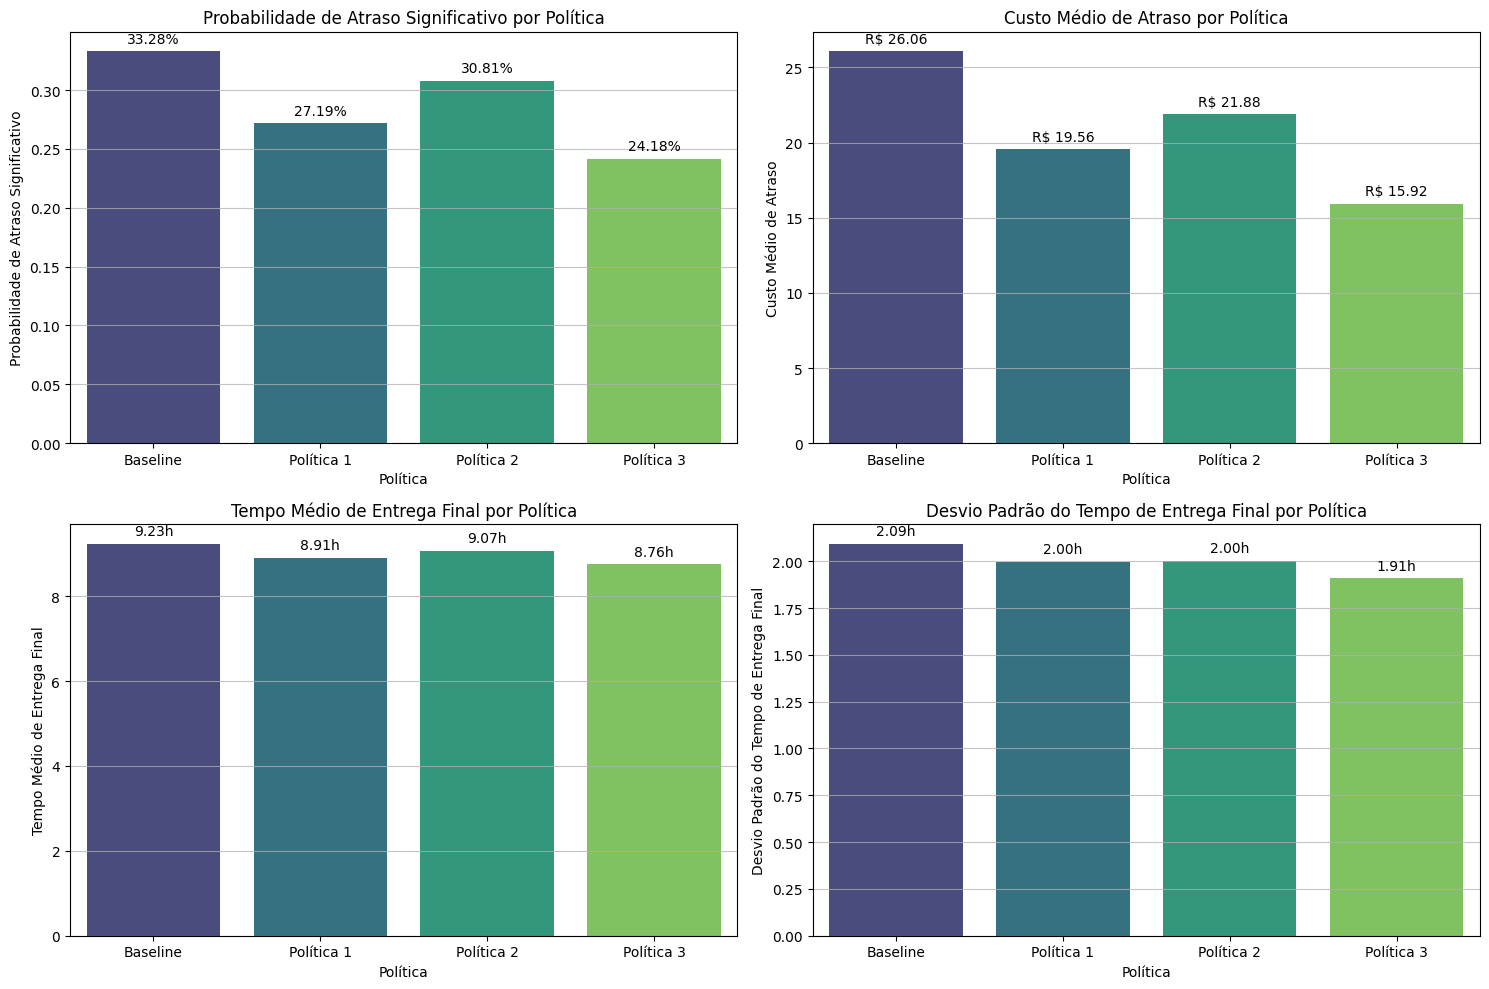

Gráficos de comparação de políticas gerados com sucesso.


In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the metrics to plot
metrics = [
    'Probabilidade de Atraso Significativo',
    'Custo Médio de Atraso',
    'Tempo Médio de Entrega Final',
    'Desvio Padrão do Tempo de Entrega Final'
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

for i, metric in enumerate(metrics):
    ax = axes[i]

    # Plot the bar chart
    barplot = sns.barplot(x=df_resultados.index, y=df_resultados[metric], ax=ax, palette='viridis', hue=df_resultados.index, legend=False)

    ax.set_title(f'{metric} por Política')
    ax.set_xlabel('Política')
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.75)

    # Add value labels on top of the bars by iterating over the barplot patches
    for p in barplot.patches:
        value = p.get_height()
        label = ""
        if metric == 'Probabilidade de Atraso Significativo':
            label = f'{value:.2%}'
        elif metric == 'Custo Médio de Atraso':
            label = f'R$ {value:,.2f}'
        else:
            label = f'{value:.2f}h'

        # Adjust text position
        ax.annotate(label,
                    (p.get_x() + p.get_width() / 2., value),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

plt.tight_layout()
plt.show()

print("Gráficos de comparação de políticas gerados com sucesso.")

## Tarefa Final

### Subtarefa:
Apresentar um resumo das descobertas sobre as diferentes políticas de transporte, destacando qual política é mais eficaz na redução de atrasos e custos e suas implicações para as decisões logísticas.


## Resumo:

A política mais eficaz para reduzir atrasos e custos é a Política 3, que combina a redução da probabilidade de tráfego intenso com a melhoria da capacidade operacional. Essa política reduz significativamente a probabilidade de atrasos relevantes de 33% (cenário base) para 24% e diminui o custo médio de atraso de 25,89  (cenário base) para 15,70.


Para decisões logísticas, a implicação é que uma abordagem holística, que trate múltiplas fontes de atraso (por exemplo, tanto questões de tráfego quanto operacionais), é mais impactante do que focar em um único fator. Implementar medidas que simultaneamente melhorem as condições de tráfego e a eficiência operacional produzirá os melhores resultados em termos de redução dos tempos de entrega e dos custos associados.


### Principais Resultados da Análise de Dados

*   **Definição das Políticas:** Três políticas distintas foram definidas:

    *   **Política 1:** Reduziu a probabilidade de tráfego intenso de 0,3 (cenário base) para 0,15.
    *   **Política 2:** Reduziu a probabilidade de problemas de capacidade operacional de 0,1 (cenário base) para 0,05.
    *   **Política 3:** Combinou as melhorias da Política 1 e da Política 2, definindo a probabilidade de tráfego intenso em 0,15 e a de problemas de capacidade operacional em 0,05.
*   **Melhorias de Desempenho entre as Políticas:** Todas as políticas propostas demonstraram melhoria em relação ao cenário base nas métricas principais.
*   **Política Ótima (Política 3):** Política 3, que aborda simultaneamente tráfego e capacidade operacional, apresentou consistentemente os melhores resultados:
    *   **Probabilidade de Atraso Significativo** Redução de 33% (cenário base) para 24%.
    *   **Custo Médio de Atraso:** Redução de $25,89 (cenário base) para $15,70.
    *   **Tempo Médio Final de Entrega:** Apresentou redução em relação ao cenário base.
    *   **Desvio Padrão do Tempo Final de Entregas:** Também diminuiu, indicando maior previsibilidade nos tempos de entrega.
*   **Impacto Comparativo:** Políticas focadas em fatores individuais (Política 1 para tráfego e Política 2 para capacidade operacional) também apresentaram melhorias, mas a Política 3, ao tratar ambos os aspectos, gerou os ganhos mais expressivos.

### Insights ou Próximos Passos
*   Priorizar a implementação de estratégias abrangentes que atuem em múltiplos fatores causadores de atrasos, conforme evidenciado pelo desempenho superior da Política 3.
*   Realizar uma análise de custo-benefício para implementar as mudanças necessárias para a Política 3 (por exemplo, investimentos em sistemas de gestão de tráfego ou melhorias de eficiência operacional), garantindo sua viabilidade econômica.
